# Social Media Sanctions and Misinformation Sharing

Our first job is to include anything we will need to solve this exersize. Keep in mind you will need to have the packages installed either in a virtual enviroment (recomended) or in your global python installation. To do this you can use pip:\
```pip install ```

In [9]:
import pandas as pd
import scipy.stats as stats # type: ignore
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Twitter Suspensions after the 2020 Election: Solution

First we will load our data

In [10]:
file_path = 'mosleh_et_al_data.csv'
data = pd.read_csv(file_path)

Now we shall crosstabulate! After reading the paper and the data we know that a 1 in the `suspended` column means the account was subsequently suspended and that a 1 in the `politics_hashtag` column shows that they shared `#Trump2020` during the election

In [11]:
# normalize='index' normalizes our index (just making sure thats clear)
contingency_table = pd.crosstab(data['politics_hashtag'], data['suspended'], margins=False, normalize='index')

print("Contingency Table (Row Percentages):")
print(contingency_table)

# Calculate the factor
print(f"\nTrump to No-Trump suspension factor: {contingency_table[1][1]/contingency_table[1][0]:.2f}")


Contingency Table (Row Percentages):
suspended                0         1
politics_hashtag                    
0                 0.955506  0.044494
1                 0.804218  0.195782

Trump to No-Trump suspension factor: 4.40


Now we must perform a $\chi^2$ test. Our raw contingency table is not normalized as this would add an unnecessary $\lambda$ factor to our $\chi^2$ which we don't want [cite]

In [12]:
# Create the raw contingency table for chi-squared
raw_contingency = pd.crosstab(data['politics_hashtag'], data['suspended'])
# Perform the chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(raw_contingency)
# Display chi-squared results
print("\nChi-squared Test Results:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")


Chi-squared Test Results:
Chi2 Statistic: 485.4671
P-value: 0.0000


## Distributions of Relative Frequency of Low Quality

Now we must create the two plots (We name them 1a and 1b). First thing we do is standardize our x axis with z values*


_$$*z = \frac{x - \mu}{\sigma}$$_


In [13]:
data[f'z_lowqual_pr2019_fc'] = (data["lowqual_pr2019_fc"] - data["lowqual_pr2019_fc"].mean()) / data["lowqual_pr2019_fc"].std()
data[f'z_lowqual_pr2019_crowd'] = (data["lowqual_pr2019_crowd"] - data["lowqual_pr2019_crowd"].mean()) / data["lowqual_pr2019_crowd"].std()

Now we must once again crosstabulate the data

In [14]:
# Fig 1A: Tabulate 'z_lowqual_pr2019_fc' by 'politics_hashtag'
contingency_1a = pd.crosstab(data['z_lowqual_pr2019_fc'], data['politics_hashtag'], normalize='columns')

We continue on to our visualization.\
_If you are wondering how I got them to look exactly the same as the exercise take a look at the Appendix_

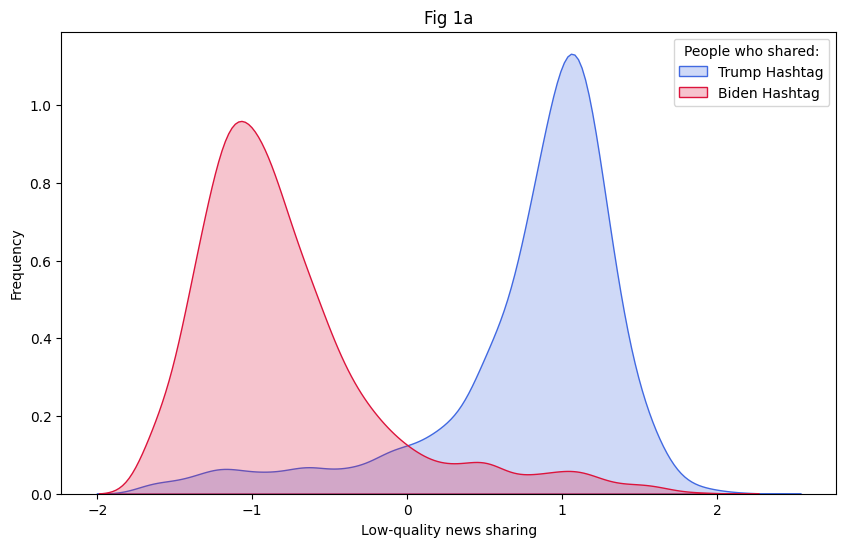

In [15]:
plt.figure(figsize=(10, 6))

# Reverse the order of plotting to change legend order to match our exersize
for hashtag in sorted(data['politics_hashtag'].unique(), reverse=True):
   sns.kdeplot(
       data=data[data['politics_hashtag'] == hashtag], 
       x='z_lowqual_pr2019_fc', 
       fill=True,
       color='#dc143c' if hashtag == 0 else '#4169e1',
       alpha=0.25,
       label='Biden Hashtag' if hashtag == 0 else 'Trump Hashtag'
   )

plt.xlabel('Low-quality news sharing')
plt.ylabel('Frequency')
plt.title('Fig 1a')
plt.legend(title='People who shared:')
plt.show()

We do exactly the same steps for our second figure

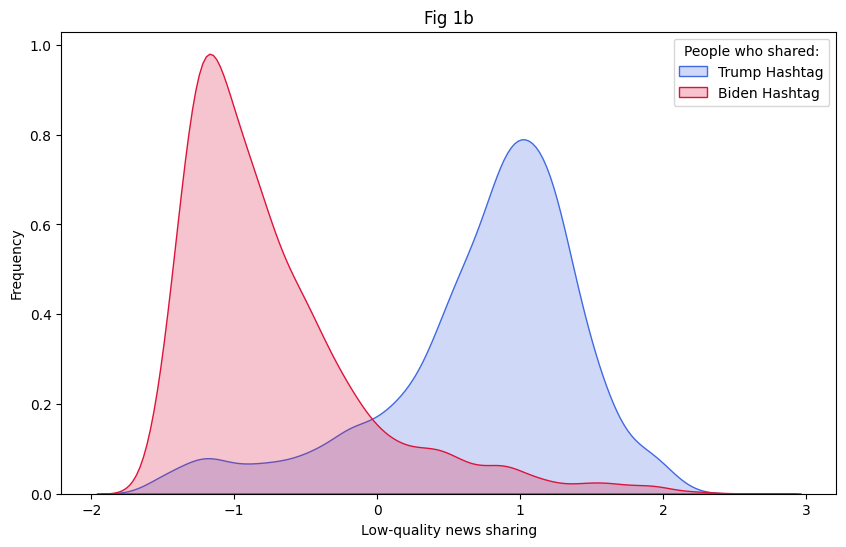

In [16]:
# Fig 1B: Tabulate 'z_lowqual_pr2019_crowd' by 'politics_hashtag'
contingency_1b = pd.crosstab(data['z_lowqual_pr2019_crowd'], data['politics_hashtag'], normalize='columns')

plt.figure(figsize=(10, 6))

for hashtag in sorted(data['politics_hashtag'].unique(), reverse=True):
    sns.kdeplot(
        data=data[data['politics_hashtag'] == hashtag], 
        x='z_lowqual_pr2019_crowd', 
        fill=True,
        color='#dc143c' if hashtag == 0 else '#4169e1',
        alpha=0.25,
        label='Biden Hashtag' if hashtag == 0 else 'Trump Hashtag'
    )

plt.xlabel('Low-quality news sharing')
plt.ylabel('Frequency')
plt.title('Fig 1b')
plt.legend(title='People who shared:')
plt.show()


## Low-quality News Sharing on Twitter

### Sharing Lower-quality News Sources and Conservative Ideology

## News Sharing Can Help Explain Suspension, Using Single Predictors

## News Sharing Can Help Explain Suspension, Using Multiple Predictors

## Appendix

### Diagram Carbon Copy Technique

In order to make my diagrams a carbon copy of the ones in the exercise I followed the following process.\
The diagrams were given to us as svg's so I went through the structure metadata in order to find exactly the plotting used. The tag Agent shows us it was created using `Matplotlib v3.9.2` (which is the underlying agent of Seaborn too). The next thing we need are the colors used. These could be sampled from the diagram using a pixel analysis but this might give us bad results partly depending on our render or rastering. So I once again went through the svg data to find the fill styles. I found the following snipets of code:\
`" style="fill: #dc143c; fill-opacity: 0.25; stroke: #dc143c; stroke-linejoin: miter"/>`\
`" style="fill: #4169e1; fill-opacity: 0.25; stroke: #4169e1; stroke-linejoin: miter"/>`\
Which not only gave me the color hex but also the alpha of the fill.